### References
The codes in this notebook use reference from the following sources
1. https://github.com/jahongir7174/YOLOv8-dfl/tree/master 
2. https://arxiv.org/html/2304.00501v6/#S16
3. https://github.com/ultralytics/ultralytics/tree/main/ultralytics/models/yolo

In [2]:
# import
import math, os, random, cv2, numpy, torch
import torch.nn as nn
from ultralytics import YOLO

# explore the original yolov8 model

# original yolov8n
model_n=YOLO('yolov8n.pt')
print(f"yolov8-nano: {sum(p.numel() for p in model_n.parameters())/1e6} million parameters")


# model_s=YOLO('yolov8s.pt')
# print(f"yolov8-small: {sum(p.numel() for p in model_s.parameters())/1e6} million parameters")

print(model_n.model)



yolov8-nano: 3.1572 million parameters
DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
       

## Yolov8 architecture
The overall architecture is BackBone + Neck + Head

<center>
<img src="yolov8_architecture.png" width="700" height="700">

## 1. Backbone
The backbone is modified CSPDarknet53 which comprises of blocks Conv, C2f, SPPF
1. **Conv**: Conv2d + BatchNorm2d + SiLU 
2. **C2f (cross-stage partial bottleneck with 2 convolutions)**: Conv + Bottlenecks + Conv <br>
Combine high-level features with contextual information to improve detection accuracy.
3. **SPPF (spatial pyramid pooling fast)**: Conv + Maxpool2d + Conv <br>
Process features at various scales and pool them into a fixed-size feature map. 

### (a) Conv 

In [3]:
class Conv(nn.Module):
    def __init__(self,in_channels, out_channels,kernel_size=3,stride=1,padding=1,groups=1,activation=True):
        super().__init__()
        self.conv=nn.Conv2d(in_channels,out_channels,kernel_size,stride,padding,bias=False,groups=groups)
        self.bn=nn.BatchNorm2d(out_channels,eps=0.001,momentum=0.03)
        self.act=nn.SiLU(inplace=True) if activation else nn.Identity()

    def forward(self,x):
        return self.act(self.bn(self.conv(x)))

### (b) C2f

In [4]:
# 2.1 Bottleneck: staack of 2 COnv with shortcut connnection (True/False)
class Bottleneck(nn.Module):
    def __init__(self,in_channels,out_channels,shortcut=True):
        super().__init__()
        self.conv1=Conv(in_channels,out_channels,kernel_size=3,stride=1,padding=1)
        self.conv2=Conv(out_channels,out_channels,kernel_size=3,stride=1,padding=1)
        self.shortcut=shortcut

    def forward(self,x):
        x_in=x # for residual connection
        x=self.conv1(x)
        x=self.conv2(x)
        if self.shortcut:
            x=x+x_in
        return x
    
# 2.2 C2f: Conv + bottleneck*N+ Conv
class C2f(nn.Module):
    def __init__(self,in_channels,out_channels, num_bottlenecks,shortcut=True):
        super().__init__()
        
        self.mid_channels=out_channels//2
        self.num_bottlenecks=num_bottlenecks

        self.conv1=Conv(in_channels,out_channels,kernel_size=1,stride=1,padding=0)
        
        # sequence of bottleneck layers
        self.m=nn.ModuleList([Bottleneck(self.mid_channels,self.mid_channels) for _ in range(num_bottlenecks)])

        self.conv2=Conv((num_bottlenecks+2)*out_channels//2,out_channels,kernel_size=1,stride=1,padding=0)
    
    def forward(self,x):
        x=self.conv1(x)

        # split x along channel dimension
        x1,x2=x[:,:x.shape[1]//2,:,:], x[:,x.shape[1]//2:,:,:]
        
        # list of outputs
        outputs=[x1,x2] # x1 is fed through the bottlenecks

        for i in range(self.num_bottlenecks):
            x1=self.m[i](x1)    # [bs,0.5c_out,w,h]
            outputs.insert(0,x1)

        outputs=torch.cat(outputs,dim=1) # [bs,0.5c_out(num_bottlenecks+2),w,h]
        out=self.conv2(outputs)

        return out
         
# sanity check
c2f=C2f(in_channels=64,out_channels=128,num_bottlenecks=2)
print(f"{sum(p.numel() for p in c2f.parameters())/1e6} million parameters")

dummy_input=torch.rand((1,64,244,244))
dummy_input=c2f(dummy_input)
print("Output shape: ", dummy_input.shape)


0.18944 million parameters
Output shape:  torch.Size([1, 128, 244, 244])
Output shape:  torch.Size([1, 128, 244, 244])


### (c) SPPF

In [5]:
class SPPF(nn.Module):
    def __init__(self,in_channels,out_channels,kernel_size=5):
        #kernel_size= size of maxpool
        super().__init__()
        hidden_channels=in_channels//2
        self.conv1=Conv(in_channels,hidden_channels,kernel_size=1,stride=1,padding=0)
        # concatenate outputs of maxpool and feed to conv2
        self.conv2=Conv(4*hidden_channels,out_channels,kernel_size=1,stride=1,padding=0)

        # maxpool is applied at 3 different sacles
        self.m=nn.MaxPool2d(kernel_size=kernel_size,stride=1,padding=kernel_size//2,dilation=1,ceil_mode=False)
    
    def forward(self,x):
        x=self.conv1(x)

        # apply maxpooling at diffent scales
        y1=self.m(x)
        y2=self.m(y1)
        y3=self.m(y2)

        # concantenate 
        y=torch.cat([x,y1,y2,y3],dim=1)

        # final conv
        y=self.conv2(y)

        return y

# sanity check
sppf=SPPF(in_channels=128,out_channels=512)
print(f"{sum(p.numel() for p in sppf.parameters())/1e6} million parameters")

dummy_input=sppf(dummy_input)
print("Output shape: ", dummy_input.shape)


0.140416 million parameters
Output shape:  torch.Size([1, 512, 244, 244])
Output shape:  torch.Size([1, 512, 244, 244])


### Putting things together

In [6]:
# backbone = DarkNet53

# return d,w,r based on version
def yolo_params(version):
    if version=='n':
        return 1/3,1/4,2.0
    elif version=='s':
        return 1/3,1/2,2.0
    elif version=='m':
        return 2/3,3/4,1.5
    elif version=='l':
        return 1.0,1.0,1.0
    elif version=='x':
        return 1.0,1.25,1.0
    
class Backbone(nn.Module):
    def __init__(self,version,in_channels=3,shortcut=True):
        super().__init__()
        d,w,r=yolo_params(version)

        # conv layers
        self.conv_0=Conv(in_channels,int(64*w),kernel_size=3,stride=2,padding=1)
        self.conv_1=Conv(int(64*w),int(128*w),kernel_size=3,stride=2,padding=1)
        self.conv_3=Conv(int(128*w),int(256*w),kernel_size=3,stride=2,padding=1)
        self.conv_5=Conv(int(256*w),int(512*w),kernel_size=3,stride=2,padding=1)
        self.conv_7=Conv(int(512*w),int(512*w*r),kernel_size=3,stride=2,padding=1)

        # c2f layers
        self.c2f_2=C2f(int(128*w),int(128*w),num_bottlenecks=int(3*d),shortcut=True)
        self.c2f_4=C2f(int(256*w),int(256*w),num_bottlenecks=int(6*d),shortcut=True)
        self.c2f_6=C2f(int(512*w),int(512*w),num_bottlenecks=int(6*d),shortcut=True)
        self.c2f_8=C2f(int(512*w*r),int(512*w*r),num_bottlenecks=int(3*d),shortcut=True)

        # sppf
        self.sppf=SPPF(int(512*w*r),int(512*w*r))
    
    def forward(self,x):
        x=self.conv_0(x)
        x=self.conv_1(x)

        x=self.c2f_2(x)

        x=self.conv_3(x)

        out1=self.c2f_4(x) # keep for output

        x=self.conv_5(out1)

        out2=self.c2f_6(x) # keep for output

        x=self.conv_7(out2)
        x=self.c2f_8(x)
        out3=self.sppf(x)

        return out1,out2,out3

print("----Nano model -----")
backbone_n=Backbone(version='n')
print(f"{sum(p.numel() for p in backbone_n.parameters())/1e6} million parameters")

print("----Small model -----")
backbone_s=Backbone(version='s')
print(f"{sum(p.numel() for p in backbone_s.parameters())/1e6} million parameters")
        

        


----Nano model -----
1.272656 million parameters
----Small model -----
5.079712 million parameters


In [7]:
# sanity check
x=torch.rand((1,3,640,640))
out1,out2,out3=backbone_n(x)
print(out1.shape)
print(out2.shape)
print(out3.shape)

torch.Size([1, 64, 80, 80])
torch.Size([1, 128, 40, 40])
torch.Size([1, 256, 20, 20])


## 2. Neck
The neck comprises of Upsample + C2f with 

**Upsample** = nearest-neighbor interpolation with scale_factor=2. It doesn't have trainable paramaters.

In [8]:
# upsample = nearest-neighbor interpolation with scale_factor=2
#            doesn't have trainable paramaters
class Upsample(nn.Module):
    def __init__(self,scale_factor=2,mode='nearest'):
        super().__init__()
        self.scale_factor=scale_factor
        self.mode=mode

    def forward(self,x):
        return nn.functional.interpolate(x,scale_factor=self.scale_factor,mode=self.mode)
    
    


In [9]:
class Neck(nn.Module):
    def __init__(self,version):
        super().__init__()
        d,w,r=yolo_params(version)

        self.up=Upsample() # no trainable parameters
        self.c2f_1=C2f(in_channels=int(512*w*(1+r)), out_channels=int(512*w),num_bottlenecks=int(3*d),shortcut=False)
        self.c2f_2=C2f(in_channels=int(768*w), out_channels=int(256*w),num_bottlenecks=int(3*d),shortcut=False)
        self.c2f_3=C2f(in_channels=int(768*w), out_channels=int(512*w),num_bottlenecks=int(3*d),shortcut=False)
        self.c2f_4=C2f(in_channels=int(512*w*(1+r)), out_channels=int(512*w*r),num_bottlenecks=int(3*d),shortcut=False)

        self.cv_1=Conv(in_channels=int(256*w),out_channels=int(256*w),kernel_size=3,stride=2, padding=1)
        self.cv_2=Conv(in_channels=int(512*w),out_channels=int(512*w),kernel_size=3,stride=2, padding=1)


    def forward(self,x_res_1,x_res_2,x):    
        # x_res_1,x_res_2,x = output of backbone
        res_1=x              # for residual connection
        
        x=self.up(x)
        x=torch.cat([x,x_res_2],dim=1)

        res_2=self.c2f_1(x)  # for residual connection
        
        x=self.up(res_2)
        x=torch.cat([x,x_res_1],dim=1)

        out_1=self.c2f_2(x)

        x=self.cv_1(out_1)

        x=torch.cat([x,res_2],dim=1)
        out_2=self.c2f_3(x)

        x=self.cv_2(out_2)

        x=torch.cat([x,res_1],dim=1)
        out_3=self.c2f_4(x)

        return out_1,out_2,out_3
    
# sanity check
neck=Neck(version='n')
print(f"{sum(p.numel() for p in neck.parameters())/1e6} million parameters")

x=torch.rand((1,3,640,640))
out1,out2,out3=Backbone(version='n')(x)
out_1,out_2,out_3=neck(out1,out2,out3)
print(out_1.shape)
print(out_2.shape)
print(out_3.shape)



0.98688 million parameters
torch.Size([1, 64, 80, 80])
torch.Size([1, 128, 40, 40])
torch.Size([1, 256, 20, 20])


## 3. Head
Consist of 3 modules: (1) bbox coordinates, (2) classification scores, (3) distribution focal loss (DFL).

**DFL** considers the predicted bbox coordinates as a probability distribution. At inference time, it samples from the distribution to get **refined coordinates** $(x,y,w,h)$. For example, to predict coordinate $x$ in the normalized range $[0,1]$:
1. DFL uses 16 bins which are equally spaced in $[0,1]$, bin length = 1/16. 
2. The model outputs 16 numbers which corresponds to probabilities that x falls in these bins, for example, $[0,0,...,9/10,1/10]$.
3. Prediction for $x=$ mean value $= 9/10\cdot15/16+1/10\cdot 1=0.94375$ 


### (a) DFL

In [10]:
# DFL
class DFL(nn.Module):
    def __init__(self,ch=16):
        super().__init__()
        
        self.ch=ch
        
        self.conv=nn.Conv2d(in_channels=ch,out_channels=1,kernel_size=1,bias=False).requires_grad_(False)
        
        # initialize conv with [0,...,ch-1]
        x=torch.arange(ch,dtype=torch.float).view(1,ch,1,1)
        self.conv.weight.data[:]=torch.nn.Parameter(x) # DFL only has ch parameters

    def forward(self,x):
        # x must have num_channels = 4*ch: x=[bs,4*ch,c]
        b,c,a=x.shape                           # c=4*ch
        x=x.view(b,4,self.ch,a).transpose(1,2)  # [bs,ch,4,a]

        # take softmax on channel dimension to get distribution probabilities
        x=x.softmax(1)                          # [b,ch,4,a]
        x=self.conv(x)                          # [b,1,4,a]
        return x.view(b,4,a)                    # [b,4,a]

# sanity check
dummy_input=torch.rand((1,64,128))
dfl=DFL()
print(f"{sum(p.numel() for p in dfl.parameters())} parameters")

dummy_output=dfl(dummy_input)
print(dummy_output.shape)

print(dfl)





16 parameters
torch.Size([1, 4, 128])
DFL(
  (conv): Conv2d(16, 1, kernel_size=(1, 1), stride=(1, 1), bias=False)
)


### (b) Head

In [11]:
class Head(nn.Module):
    def __init__(self,version,ch=16,num_classes=80):

        super().__init__()
        self.ch=ch                          # dfl channels
        self.coordinates=self.ch*4          # number of bounding box coordinates 
        self.nc=num_classes                 # 80 for COCO
        self.no=self.coordinates+self.nc    # number of outputs per anchor box

        self.stride=torch.zeros(3)          # strides computed during build
        
        d,w,r=yolo_params(version=version)
        
        # for bounding boxes
        self.box=nn.ModuleList([
            nn.Sequential(Conv(int(256*w),self.coordinates,kernel_size=3,stride=1,padding=1),
                          Conv(self.coordinates,self.coordinates,kernel_size=3,stride=1,padding=1),
                          nn.Conv2d(self.coordinates,self.coordinates,kernel_size=1,stride=1)),

            nn.Sequential(Conv(int(512*w),self.coordinates,kernel_size=3,stride=1,padding=1),
                          Conv(self.coordinates,self.coordinates,kernel_size=3,stride=1,padding=1),
                          nn.Conv2d(self.coordinates,self.coordinates,kernel_size=1,stride=1)),

            nn.Sequential(Conv(int(512*w*r),self.coordinates,kernel_size=3,stride=1,padding=1),
                          Conv(self.coordinates,self.coordinates,kernel_size=3,stride=1,padding=1),
                          nn.Conv2d(self.coordinates,self.coordinates,kernel_size=1,stride=1))
        ])

        # for classification
        self.cls=nn.ModuleList([
            nn.Sequential(Conv(int(256*w),self.nc,kernel_size=3,stride=1,padding=1),
                          Conv(self.nc,self.nc,kernel_size=3,stride=1,padding=1),
                          nn.Conv2d(self.nc,self.nc,kernel_size=1,stride=1)),

            nn.Sequential(Conv(int(512*w),self.nc,kernel_size=3,stride=1,padding=1),
                          Conv(self.nc,self.nc,kernel_size=3,stride=1,padding=1),
                          nn.Conv2d(self.nc,self.nc,kernel_size=1,stride=1)),

            nn.Sequential(Conv(int(512*w*r),self.nc,kernel_size=3,stride=1,padding=1),
                          Conv(self.nc,self.nc,kernel_size=3,stride=1,padding=1),
                          nn.Conv2d(self.nc,self.nc,kernel_size=1,stride=1))
        ])

        # dfl
        self.dfl=DFL()

    def forward(self,x):
        # x = output of Neck = list of 3 tensors with different resolution and different channel dim
        #     x[0]=[bs, ch0, w0, h0], x[1]=[bs, ch1, w1, h1], x[2]=[bs,ch2, w2, h2] 

        for i in range(len(self.box)):       # detection head i
            box=self.box[i](x[i])            # [bs,num_coordinates,w,h]
            cls=self.cls[i](x[i])            # [bs,num_classes,w,h]
            x[i]=torch.cat((box,cls),dim=1)  # [bs,num_coordinates+num_classes,w,h]

        # in training, no dfl output
        if self.training:
            return x                         # [3,bs,num_coordinates+num_classes,w,h]
        
        # in inference time, dfl produces refined bounding box coordinates
        anchors, strides = (i.transpose(0, 1) for i in self.make_anchors(x, self.stride))

        # concatenate predictions from all detection layers
        x = torch.cat([i.view(x[0].shape[0], self.no, -1) for i in x], dim=2) #[bs, 4*self.ch + self.nc, sum_i(h[i]w[i])]
        
        # split out predictions for box and cls
        #           box=[bs,4×self.ch,sum_i(h[i]w[i])]
        #           cls=[bs,self.nc,sum_i(h[i]w[i])]
        box, cls = x.split(split_size=(4 * self.ch, self.nc), dim=1)


        a, b = self.dfl(box).chunk(2, 1)  # a=b=[bs,2×self.ch,sum_i(h[i]w[i])]
        a = anchors.unsqueeze(0) - a
        b = anchors.unsqueeze(0) + b
        box = torch.cat(tensors=((a + b) / 2, b - a), dim=1)
        
        return torch.cat(tensors=(box * strides, cls.sigmoid()), dim=1)


    def make_anchors(self, x, strides, offset=0.5):
        # x= list of feature maps: x=[x[0],...,x[N-1]], in our case N= num_detection_heads=3
        #                          each having shape [bs,ch,w,h]
        #    each feature map x[i] gives output[i] = w*h anchor coordinates + w*h stride values
        
        # strides = list of stride values indicating how much 
        #           the spatial resolution of the feature map is reduced compared to the original image

        assert x is not None
        anchor_tensor, stride_tensor = [], []
        dtype, device = x[0].dtype, x[0].device
        for i, stride in enumerate(strides):
            _, _, h, w = x[i].shape
            sx = torch.arange(end=w, device=device, dtype=dtype) + offset  # x coordinates of anchor centers
            sy = torch.arange(end=h, device=device, dtype=dtype) + offset  # y coordinates of anchor centers
            sy, sx = torch.meshgrid(sy, sx)                                # all anchor centers 
            anchor_tensor.append(torch.stack((sx, sy), -1).view(-1, 2))
            stride_tensor.append(torch.full((h * w, 1), stride, dtype=dtype, device=device))
        return torch.cat(anchor_tensor), torch.cat(stride_tensor)
        

In [12]:

detect=Head(version='n')
print(f"{sum(p.numel() for p in detect.parameters())/1e6} million parameters")

# out_1,out_2,out_3 are output of the neck
output=detect([out_1,out_2,out_3])
print(output[0].shape)
print(output[1].shape)
print(output[2].shape)

print(detect)


0.897664 million parameters
torch.Size([1, 144, 80, 80])
torch.Size([1, 144, 40, 40])
torch.Size([1, 144, 20, 20])
Head(
  (box): ModuleList(
    (0): Sequential(
      (0): Conv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    )
    (1): Sequential(
      (0): Conv(
        (conv): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

## 4. Putting everything together

In [13]:
class MyYolo(nn.Module):
    def __init__(self,version):
        super().__init__()
        self.backbone=Backbone(version=version)
        self.neck=Neck(version=version)
        self.head=Head(version=version)

    def forward(self,x):
        x=self.backbone(x)              # return out1,out2,out3
        x=self.neck(x[0],x[1],x[2])     # return out_1, out_2,out_3
        return self.head(list(x))
    
model=MyYolo(version='n')
print(f"{sum(p.numel() for p in model.parameters())/1e6} million parameters")
print(model)

3.1572 million parameters
MyYolo(
  (backbone): Backbone(
    (conv_0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (conv_1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (conv_3): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (conv_5): Conv(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (

## 5. Dataset and Train
Due to computation constraint, we will only overfit 1 batch of data from YOLO2017. The loss in yolov8 consists  (1) box_loss, (2) classification_loss, (3) dfl_loss
1. **Box loss**: on bounding box coordinates
2. **Classification loss**: on classification logits
3. **DFL_Loss**: itegrated in box loss

**How DFL loss works?**
1. Target distribution = single value over 16 bins, this value will be smooth between 2 bin centers. For example, if target value is in the middle of bin 1 and 2, target distribution $= [1/2,1/2,0,...,0]$
2. Predicted distribution is based on the output of bbox coordinates. These outputs can be used to compute the probabilities for each bin, say $[1/16,1/16,...,1/16]$
3. DFL = cross entropy between prediction and target

The utils file for computing loss is taken from https://github.com/jahongir7174/YOLOv8-dfl/tree/master

In [ ]:
import yaml
from utils.dataset import *
from torch.utils import data

# get all file names
data_dir= 'COCO'
filenames_train = []
with open(f'{data_dir}/val2017.txt') as reader:
    for filename in reader.readlines():
        filename = os.path.basename(filename.rstrip())
        filenames_train.append(f'{data_dir}/images/val2017/' + filename)

print(f"filname: {filenames_train[0]}")

# input_size for the model
input_size=640

# get params from yaml file
with open('utils/args.yaml', errors='ignore') as f:
        params = yaml.safe_load(f)

# Use small batch size and disable augmentation to save GPU memory
train_data=Dataset(filenames_train,input_size,params,augment=False)
train_loader = data.DataLoader(train_data, batch_size=2, num_workers=0, pin_memory=False, collate_fn=Dataset.collate_fn)
print(f"Train_loader : {len(train_loader)} batches")


filnameCOCO/images/val2017/000000000139.jpg
Train_loader : 2500 batches
Train_loader : 2500 batches


In [14]:
batch=next(iter(train_loader))
print("All keys in batch      : ", batch[1].keys())
print(f"Input batch shape      : ", batch[0].shape)
print(f"Classification scores  : {batch[1]['cls'].shape}")
print(f"Box coordinates        : {batch[1]['box'].shape}")
print(f"Index identifier (which score belongs to which image): {batch[1]['idx'].shape}")

All keys in batch      :  dict_keys(['cls', 'box', 'idx'])
Input batch shape      :  torch.Size([2, 3, 640, 640])
Classification scores  : torch.Size([21, 1])
Box coordinates        : torch.Size([21, 4])
Index identifier (which score belongs to which image): torch.Size([21])


In [15]:
from utils import util
torch.manual_seed(1337)

# Set device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# model, loss and optimizer
model=MyYolo(version='n').to(device)
print(f"{sum(p.numel() for p in model.parameters())/1e6} million parameters")

criterion=util.ComputeLoss(model, params)
# Reduce learning rate to a reasonable value
optimizer=torch.optim.AdamW(model.parameters(), lr=0.001)

num_epochs=5

imgs,targets=batch[0],batch[1]
imgs=imgs.float().to(device)
# Move targets to device
targets['cls'] = targets['cls'].to(device)
targets['box'] = targets['box'].to(device)
targets['idx'] = targets['idx'].to(device)

model.train()
for epoch in range(num_epochs):
    outputs=model(imgs)
    loss=sum(criterion(outputs,targets)) # cls_loss+box_loss+dfl_loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch : {epoch} | loss : {loss.item()}")


Using device: cuda
3.1572 million parameters
3.1572 million parameters


/home/adrien/venv/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Epoch : 0 | loss : 478008.5
Epoch : 1 | loss : 467854.65625
Epoch : 2 | loss : 461398.65625
Epoch : 3 | loss : 455033.21875
Epoch : 4 | loss : 448299.75


: 

## 6. Pose Detection Extension
We can extend the model to detect poses (lying, sitting, standing) using the OVAD dataset. This adds a pose classification branch to the detection head.

**Key modifications:**
1. **HeadWithPose**: Adds a pose classification branch (3 classes) alongside bbox and object classification
2. **OVADDataset**: Loads OVAD annotations with pose labels for person category
3. **ComputeLossWithPose**: Adds pose classification loss (cross-entropy) to existing losses

**Pose classes:**
- 0: lying/horizontal
- 1: sitting
- 2: standing/vertical

In [17]:
# Import the new components
import sys
sys.path.append('utils')

from head_with_pose import HeadWithPose
from ovad_dataset import OVADDataset
from loss_with_pose import ComputeLossWithPose

# Create model with pose detection head
class MyYoloWithPose(nn.Module):
    def __init__(self, version):
        super().__init__()
        self.backbone = Backbone(version=version)
        self.neck = Neck(version=version)
        self.head = HeadWithPose(version=version, num_classes=80, num_poses=3)

    def forward(self, x):
        x = self.backbone(x)
        x = self.neck(x[0], x[1], x[2])
        return self.head(list(x))

# Initialize model
model_pose = MyYoloWithPose(version='n')
model_pose.head.stride = torch.tensor([8.0, 16.0, 32.0])
print(f"Model with pose detection: {sum(p.numel() for p in model_pose.parameters())/1e6:.2f}M parameters")

# Show the additional pose head
print("\nPose classification heads:")
for i, pose_head in enumerate(model_pose.head.pose):
    num_params = sum(p.numel() for p in pose_head.parameters())
    print(f"  Head {i}: {num_params} parameters")

Model with pose detection: 3.17M parameters

Pose classification heads:
  Head 0: 1833 parameters
  Head 1: 3561 parameters
  Head 2: 7017 parameters


In [18]:
# Load OVAD dataset with pose annotations
ovad_json_path = '../ovad/ovad2000.json'
coco_img_dir = 'COCO/images/val2017'

# Load params if not already defined
if 'params' not in dir():
    import yaml
    with open('utils/args.yaml', errors='ignore') as f:
        params = yaml.safe_load(f)

# Check if OVAD file exists
import os
if not os.path.exists(ovad_json_path):
    print(f"Warning: OVAD file not found at {ovad_json_path}")
    print("Please ensure the ovad2000.json file is in the correct location.")
else:
    # Create dataset
    ovad_dataset = OVADDataset(
        ovad_json_path=ovad_json_path,
        coco_img_dir=coco_img_dir,
        input_size=640,
        params=params,
        augment=False
    )
    
    print(f"\nDataset loaded successfully!")
    print(f"Number of images: {len(ovad_dataset)}")
    print(f"Pose classes: {ovad_dataset.pose_classes}")
    
    # Create dataloader
    from torch.utils.data import DataLoader
    pose_loader = DataLoader(
        ovad_dataset,
        batch_size=2,
        shuffle=True,
        num_workers=0,
        pin_memory=False,
        collate_fn=OVADDataset.collate_fn
    )
    
    print(f"Number of batches: {len(pose_loader)}")
    
    # Get a sample batch
    sample_batch = next(iter(pose_loader))
    images, targets = sample_batch
    
    print(f"\nSample batch:")
    print(f"  Images shape: {images.shape}")
    print(f"  Number of objects: {len(targets['cls'])}")
    print(f"  Pose labels: {targets['pose']}")
    print(f"  Pose distribution: lying={sum(targets['pose']==0)}, sitting={sum(targets['pose']==1)}, standing={sum(targets['pose']==2)}")

Loading OVAD dataset from ../ovad/ovad2000.json...
Loaded 986 images with 3915 person annotations with pose

Dataset loaded successfully!
Number of images: 986
Pose classes: ['lying', 'sitting', 'standing']
Number of batches: 493

Sample batch:
  Images shape: torch.Size([2, 3, 640, 640])
  Number of objects: 6
  Pose labels: tensor([0, 0, 2, 2, 2, 2])
  Pose distribution: lying=2, sitting=0, standing=4
Loaded 986 images with 3915 person annotations with pose

Dataset loaded successfully!
Number of images: 986
Pose classes: ['lying', 'sitting', 'standing']
Number of batches: 493

Sample batch:
  Images shape: torch.Size([2, 3, 640, 640])
  Number of objects: 6
  Pose labels: tensor([0, 0, 2, 2, 2, 2])
  Pose distribution: lying=2, sitting=0, standing=4


In [19]:
# Train the model with pose detection
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move model to device
model_pose = model_pose.to(device)

# Setup loss and optimizer
params_pose = params.copy()
params_pose['pose'] = 1.0  # weight for pose loss

criterion_pose = ComputeLossWithPose(model_pose, params_pose, num_poses=3)
optimizer_pose = torch.optim.AdamW(model_pose.parameters(), lr=0.001)

# Training loop (overfit on one batch for demonstration)
num_epochs = 5

# Get one batch
images_pose, targets_pose = sample_batch
images_pose = images_pose.float().to(device)
targets_pose['cls'] = targets_pose['cls'].to(device)
targets_pose['box'] = targets_pose['box'].to(device)
targets_pose['idx'] = targets_pose['idx'].to(device)
targets_pose['pose'] = targets_pose['pose'].to(device)

model_pose.train()
print("\nTraining with pose detection:")
for epoch in range(num_epochs):
    outputs = model_pose(images_pose)
    loss_box, loss_cls, loss_dfl, loss_pose = criterion_pose(outputs, targets_pose)
    total_loss = loss_box + loss_cls + loss_dfl + loss_pose
    
    optimizer_pose.zero_grad()
    total_loss.backward()
    optimizer_pose.step()
    
    print(f"Epoch {epoch}: total={total_loss.item():.4f} | box={loss_box.item():.4f} | cls={loss_cls.item():.4f} | dfl={loss_dfl.item():.4f} | pose={loss_pose.item():.4f}")

Using device: cuda

Training with pose detection:

Training with pose detection:


/home/adrien/venv/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Epoch 0: total=57179.4062 | box=3.4214 | cls=57165.1328 | dfl=4.5392 | pose=6.3139
Epoch 1: total=56850.3828 | box=2.6767 | cls=56838.2188 | dfl=4.3045 | pose=5.1846
Epoch 2: total=60717.5273 | box=2.1665 | cls=60706.9336 | dfl=3.8493 | pose=4.5794
Epoch 3: total=46989.2539 | box=1.4596 | cls=46980.7266 | dfl=3.6795 | pose=3.3877
Epoch 4: total=59673.8906 | box=1.7132 | cls=59664.0938 | dfl=3.5563 | pose=4.5273
Epoch 4: total=59673.8906 | box=1.7132 | cls=59664.0938 | dfl=3.5563 | pose=4.5273


### Inference with Pose Detection

In inference mode, the model outputs:
- **Boxes**: 4 values (x, y, w, h) - refined with DFL
- **Class scores**: 80 values (COCO classes) - sigmoid activated
- **Pose scores**: 3 values (lying, sitting, standing) - sigmoid activated

Total output channels: 4 + 80 + 3 = **87 channels**

In [20]:
# Test inference mode
model_pose.eval()
with torch.no_grad():
    test_image = torch.rand(1, 3, 640, 640).to(device)
    inference_output = model_pose(test_image)
    
    print(f"Inference output shape: {inference_output.shape}")
    print(f"Expected: [batch_size, 87, num_anchors]")
    print(f"  - Channels 0-3: Bounding box (x, y, w, h)")
    print(f"  - Channels 4-83: Object class scores (80 classes)")
    print(f"  - Channels 84-86: Pose scores (lying, sitting, standing)")
    
    # Extract pose predictions
    boxes = inference_output[:, :4, :]
    class_scores = inference_output[:, 4:84, :]
    pose_scores = inference_output[:, 84:87, :]
    
    print(f"\nSplit outputs:")
    print(f"  Boxes: {boxes.shape}")
    print(f"  Class scores: {class_scores.shape}")
    print(f"  Pose scores: {pose_scores.shape}")
    
    # Find max pose for each anchor
    pose_predictions = pose_scores.argmax(dim=1)
    pose_names = ['lying', 'sitting', 'standing']
    
    # Show distribution of pose predictions
    unique, counts = torch.unique(pose_predictions, return_counts=True)
    print(f"\nPose prediction distribution:")
    for pose_id, count in zip(unique.cpu(), counts.cpu()):
        print(f"  {pose_names[pose_id]}: {count} anchors")

Inference output shape: torch.Size([1, 87, 8400])
Expected: [batch_size, 87, num_anchors]
  - Channels 0-3: Bounding box (x, y, w, h)
  - Channels 4-83: Object class scores (80 classes)
  - Channels 84-86: Pose scores (lying, sitting, standing)

Split outputs:
  Boxes: torch.Size([1, 4, 8400])
  Class scores: torch.Size([1, 80, 8400])
  Pose scores: torch.Size([1, 3, 8400])

Pose prediction distribution:
  lying: 6400 anchors
  standing: 2000 anchors


### Visualize Pose Detection on a Real Image

**How the model works - Complete Pipeline:**

1. **Input**: One image (640×640 pixels)

2. **Model Processing** (all happens in ONE forward pass):
   - Image goes through **Backbone** → extracts features
   - Features go through **Neck** → combines multi-scale information
   - Features go through **Head** → produces 3 outputs **simultaneously**:
     - **Bounding boxes** (x, y, width, height) - where objects are
     - **Object class** (80 COCO classes: person, car, dog, etc.)
     - **Pose class** (3 poses: lying, sitting, standing) - NEW!

3. **Output**: For EACH detection, you get **all 3 things at once**:
   ```
   Detection #1: [bbox: (120, 45, 80, 150), class: person, pose: standing, confidence: 0.87]
   Detection #2: [bbox: (300, 200, 60, 40), class: person, pose: sitting, confidence: 0.92]
   ```

4. **Post-processing**:
   - Filter detections by confidence threshold (e.g., > 0.25)
   - Keep only "person" class (since poses only make sense for people)
   - Draw boxes with color-coded poses:
     - 🔴 Red = lying
     - 🔵 Blue = sitting  
     - 🟢 Green = standing

**The model does everything in ONE shot** - it's not separate steps!

In [ ]:
# Simple example: Run model on one image and show ALL detections
image_idx = 0  # Change this to try different images

if 'ovad_dataset' in dir():
    # Step 1: Get one image
    test_img_tensor, test_labels = ovad_dataset[image_idx]
    print(f"Step 1: Loaded image {image_idx}")
    print(f"  Image shape: {test_img_tensor.shape}")
    print(f"  Ground truth: {test_labels.shape[0]} people with poses\n")
    
    # Step 2: Run model (ONE forward pass)
    test_img_batch = test_img_tensor.unsqueeze(0).float().to(device)
    model_pose.eval()
    with torch.no_grad():
        predictions = model_pose(test_img_batch)
    
    print(f"Step 2: Model output")
    print(f"  Output shape: {predictions.shape}")
    print(f"  This means: [1 image, 87 values per anchor, {predictions.shape[2]} anchor points]")
    print(f"  The 87 values = 4 (bbox) + 80 (object classes) + 3 (pose classes)\n")
    
    # Step 3: Extract the 3 types of predictions
    pred_boxes = predictions[0, :4, :].cpu()           # Channels 0-3: bounding boxes
    pred_class_scores = predictions[0, 4:84, :].cpu()  # Channels 4-83: object class scores
    pred_pose_scores = predictions[0, 84:87, :].cpu()  # Channels 84-86: pose scores
    
    print(f"Step 3: Split into 3 components")
    print(f"  Bounding boxes: {pred_boxes.shape} = [4 coordinates, {pred_boxes.shape[1]} anchors]")
    print(f"  Object classes: {pred_class_scores.shape} = [80 classes, {pred_class_scores.shape[1]} anchors]")
    print(f"  Pose classes: {pred_pose_scores.shape} = [3 poses, {pred_pose_scores.shape[1]} anchors]\n")
    
    # Step 4: Filter for high-confidence "person" detections
    person_class_id = 0
    confidence_threshold = 0.25
    person_scores = pred_class_scores[person_class_id, :]
    high_conf_mask = person_scores > confidence_threshold
    
    num_detections = high_conf_mask.sum().item()
    print(f"Step 4: Filter detections")
    print(f"  Total anchors: {pred_boxes.shape[1]}")
    print(f"  High-confidence 'person' detections: {num_detections}\n")
    
    # Step 5: Show each detection with ALL its information
    if num_detections > 0:
        filtered_boxes = pred_boxes[:, high_conf_mask]
        filtered_poses = pred_pose_scores[:, high_conf_mask].argmax(dim=0)
        filtered_scores = person_scores[high_conf_mask]
        
        pose_names = ['lying', 'sitting', 'standing']
        
        print(f"Step 5: Detailed results for each detection:")
        print("=" * 80)
        for i in range(min(num_detections, 10)):  # Show first 10
            x_c, y_c, w, h = filtered_boxes[:, i].numpy()
            pose_id = int(filtered_poses[i].item())
            score = filtered_scores[i].item()
            
            print(f"\nDetection #{i+1}:")
            print(f"  └─ Bounding Box: center=({x_c:.1f}, {y_c:.1f}), size=({w:.1f}×{h:.1f}) pixels")
            print(f"  └─ Object Class: PERSON")
            print(f"  └─ Pose: {pose_names[pose_id].upper()}")
            print(f"  └─ Confidence: {score:.3f}")
        
        if num_detections > 10:
            print(f"\n... and {num_detections - 10} more detections")
        
        print("\n" + "=" * 80)
        print(f"\n✓ The model detected {num_detections} people and classified their poses")
        print(f"  ALL information (bbox + class + pose) came from ONE model inference!")
    else:
        print("No high-confidence person detections found. Try:")
        print("  - Lowering confidence_threshold")
        print("  - Choosing a different image_idx")
else:
    print("Please run the OVAD dataset loading cell first!")

Found 8400 high-confidence person detections


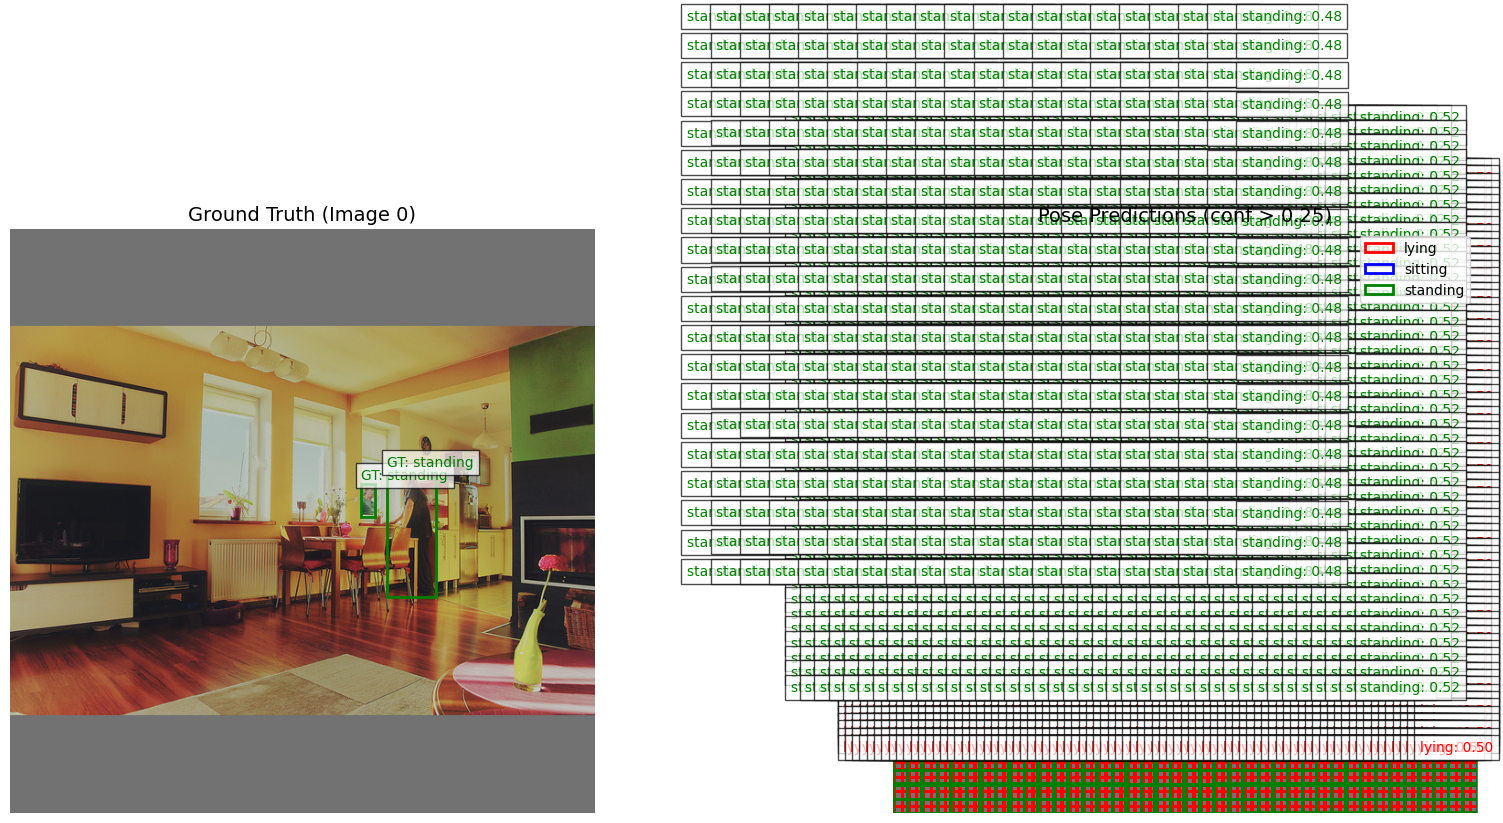


Image shape: (640, 640, 3)
Ground truth boxes: 2
Predicted boxes (conf > 0.25): 8400


In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Choose an image from the dataset
image_idx = 0  # Change this to select a different image
if 'ovad_dataset' in dir():
    # Get an image from the OVAD dataset
    test_img_tensor, test_labels = ovad_dataset[image_idx]
    
    # Convert tensor to numpy for display (CHW -> HWC)
    test_img_display = test_img_tensor.numpy().transpose(1, 2, 0).astype(np.uint8)
    
    # Prepare for model inference
    test_img_batch = test_img_tensor.unsqueeze(0).float().to(device)
    
    # Run inference
    model_pose.eval()
    with torch.no_grad():
        predictions = model_pose(test_img_batch)
    
    # predictions shape: [1, 87, num_anchors]
    # Extract boxes, class scores, and pose scores
    pred_boxes = predictions[0, :4, :].cpu()  # [4, num_anchors]
    pred_class_scores = predictions[0, 4:84, :].cpu()  # [80, num_anchors]
    pred_pose_scores = predictions[0, 84:87, :].cpu()  # [3, num_anchors]
    
    # Get max class and pose for each anchor
    max_class_scores, pred_classes = pred_class_scores.max(dim=0)
    max_pose_scores, pred_poses = pred_pose_scores.max(dim=0)
    
    # Filter by confidence threshold (keep only high-confidence person detections)
    person_class_id = 0  # person is class 0 in COCO
    confidence_threshold = 0.25
    
    # Get person class scores
    person_scores = pred_class_scores[person_class_id, :]
    high_conf_mask = person_scores > confidence_threshold
    
    # Filter predictions
    filtered_boxes = pred_boxes[:, high_conf_mask]
    filtered_poses = pred_poses[high_conf_mask]
    filtered_scores = person_scores[high_conf_mask]
    
    print(f"Found {filtered_boxes.shape[1]} high-confidence person detections")
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Left: Original image with ground truth
    ax1.imshow(test_img_display)
    ax1.set_title(f'Ground Truth (Image {image_idx})', fontsize=14)
    ax1.axis('off')
    
    # Draw ground truth boxes and poses
    pose_names = ['lying', 'sitting', 'standing']
    pose_colors = ['red', 'blue', 'green']
    
    if len(test_labels) > 0:
        for i in range(test_labels.shape[0]):
            # Labels format: [class_id, x_center, y_center, w, h, pose_label]
            x_c, y_c, w, h = test_labels[i, 1:5].numpy()
            pose_id = int(test_labels[i, 5].item())
            
            # Convert normalized to pixel coordinates
            x_c *= 640
            y_c *= 640
            w *= 640
            h *= 640
            
            # Convert to corner format
            x1 = x_c - w/2
            y1 = y_c - h/2
            
            rect = patches.Rectangle((x1, y1), w, h, linewidth=2, 
                                    edgecolor=pose_colors[pose_id], 
                                    facecolor='none')
            ax1.add_patch(rect)
            ax1.text(x1, y1-5, f'GT: {pose_names[pose_id]}', 
                    color=pose_colors[pose_id], fontsize=10, 
                    bbox=dict(facecolor='white', alpha=0.7))
    
    # Right: Predictions
    ax2.imshow(test_img_display)
    ax2.set_title(f'Pose Predictions (conf > {confidence_threshold})', fontsize=14)
    ax2.axis('off')
    
    # Draw predicted boxes and poses
    for i in range(filtered_boxes.shape[1]):
        # Boxes are in format [x_center, y_center, w, h] in pixels
        x_c, y_c, w, h = filtered_boxes[:, i].numpy()
        pose_id = int(filtered_poses[i].item())
        score = filtered_scores[i].item()
        
        # Convert to corner format
        x1 = x_c - w/2
        y1 = y_c - h/2
        
        rect = patches.Rectangle((x1, y1), w, h, linewidth=2, 
                                edgecolor=pose_colors[pose_id], 
                                facecolor='none')
        ax2.add_patch(rect)
        ax2.text(x1, y1-5, f'{pose_names[pose_id]}: {score:.2f}', 
                color=pose_colors[pose_id], fontsize=10, 
                bbox=dict(facecolor='white', alpha=0.7))
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='none', edgecolor=pose_colors[i], 
                            label=pose_names[i], linewidth=2) 
                      for i in range(3)]
    ax2.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nImage shape: {test_img_display.shape}")
    print(f"Ground truth boxes: {test_labels.shape[0]}")
    print(f"Predicted boxes (conf > {confidence_threshold}): {filtered_boxes.shape[1]}")
else:
    print("Please run the OVAD dataset loading cell first!")